Random forest


**1. Exploratory Data Analysis (EDA):**


Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.



In [16]:
import numpy as np
import pandas as pd


In [17]:
df=pd.read_excel('glass.xlsx',sheet_name='glass')

In [18]:
df

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.00,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.00,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.00,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.00,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.00,0.0,1
...,...,...,...,...,...,...,...,...,...,...
209,1.51623,14.14,0.00,2.88,72.61,0.08,9.18,1.06,0.0,7
210,1.51685,14.92,0.00,1.99,73.06,0.00,8.40,1.59,0.0,7
211,1.52065,14.36,0.00,2.02,73.42,0.00,8.44,1.64,0.0,7
212,1.51651,14.38,0.00,1.94,73.61,0.00,8.48,1.57,0.0,7


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [20]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


no null values

In [21]:
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000,214.000000
mean,1.518365,13.407850,2.684533,1.444907,72.650935,0.497056,8.956963,0.175047,0.057009,2.780374
std,0.003037,0.816604,1.442408,0.499270,0.774546,0.652192,1.423153,0.497219,0.097439,2.103739
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516522,12.907500,2.115000,1.190000,72.280000,0.122500,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.555000,8.600000,0.000000,0.000000,2.000000
75%,1.519157,13.825000,3.600000,1.630000,73.087500,0.610000,9.172500,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


**2: Data Visualization:**

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
num = df.select_dtypes(include=['float64', 'int64']).columns
num

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='object')

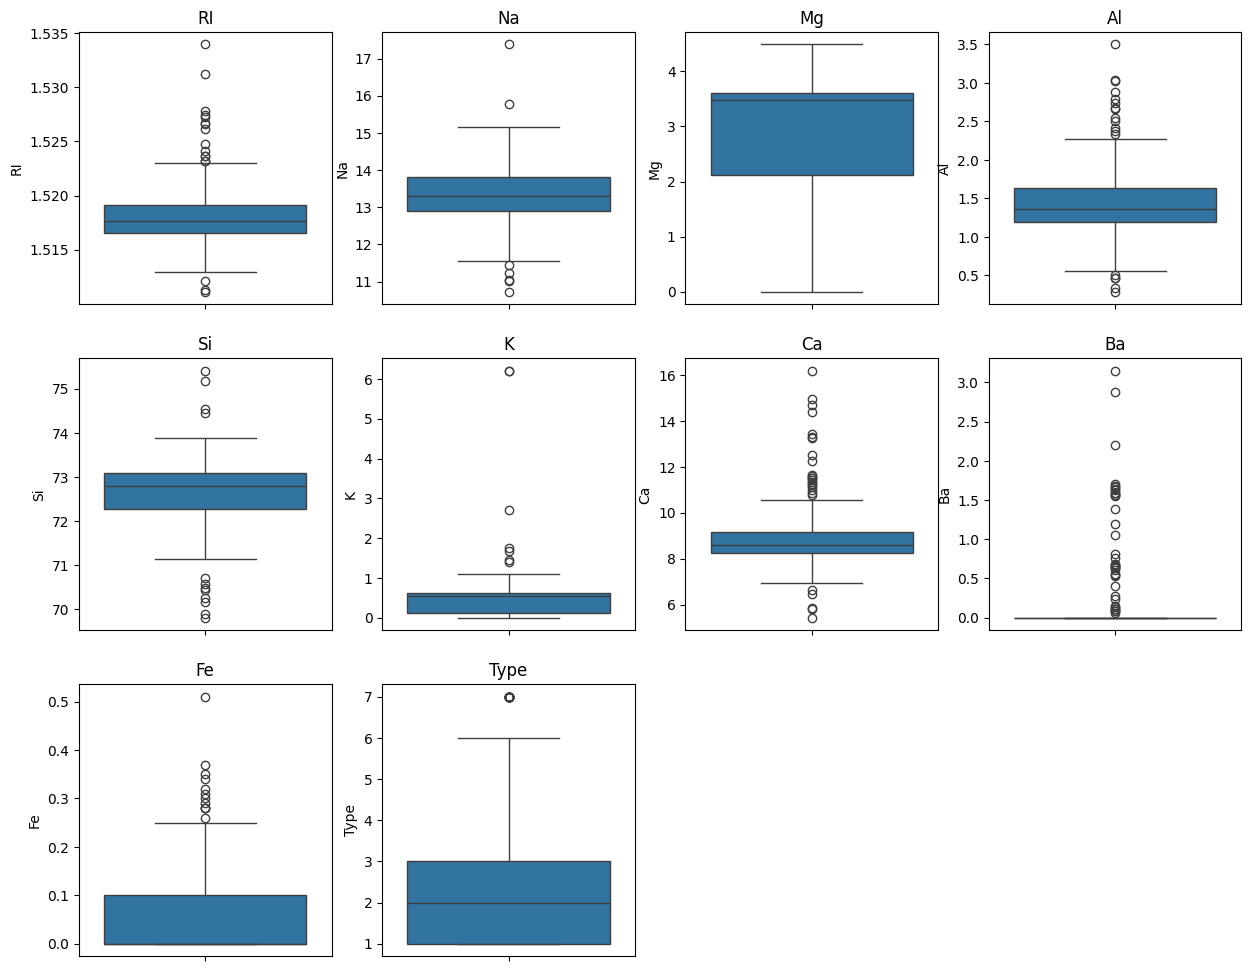

In [24]:
plt.figure(figsize=(15,12))
num_cols=len(df.columns)
num_rows=(num_cols+3)//4


for i, columns in enumerate(df.columns):
   plt.subplot(num_rows,4,i+1)
   sns.boxplot(y=df[columns])
   plt.title(columns)

plt.tight_layout
plt.show()


In [25]:
q1=df.quantile(0.25)
q3=df.quantile(0.75)
iqr=q3-q1

In [26]:
numerical_columns=df.select_dtypes(include=['float64','int64']).columns
for column in numerical_columns:

  lower_bound=q1[column]-1.5*iqr[column]
  upper_bound=q3[column]+1.5*iqr[column]
  outliers=df[(df[column]<lower_bound)|(df[column]>upper_bound)][column]
  print(f"\nColumn: {column}")
  print(f"Total outliers found: {len(outliers)}")







Column: RI
Total outliers found: 17

Column: Na
Total outliers found: 7

Column: Mg
Total outliers found: 0

Column: Al
Total outliers found: 18

Column: Si
Total outliers found: 12

Column: K
Total outliers found: 7

Column: Ca
Total outliers found: 26

Column: Ba
Total outliers found: 38

Column: Fe
Total outliers found: 12

Column: Type
Total outliers found: 29


In [27]:
df_capped=df.copy()
numerical_columns=df.select_dtypes(include=['float64','int64']).columns
for column in numerical_columns:
  lower_bound=q1[column]-1.5*iqr[column]
  upper_bound=q3[column]+1.5*iqr[column]
  df_capped[column]=np.where(df_capped[column]<lower_bound,lower_bound,df_capped[column])
  df_capped[column]=np.where(df_capped[column]>upper_bound,upper_bound,df_capped[column])



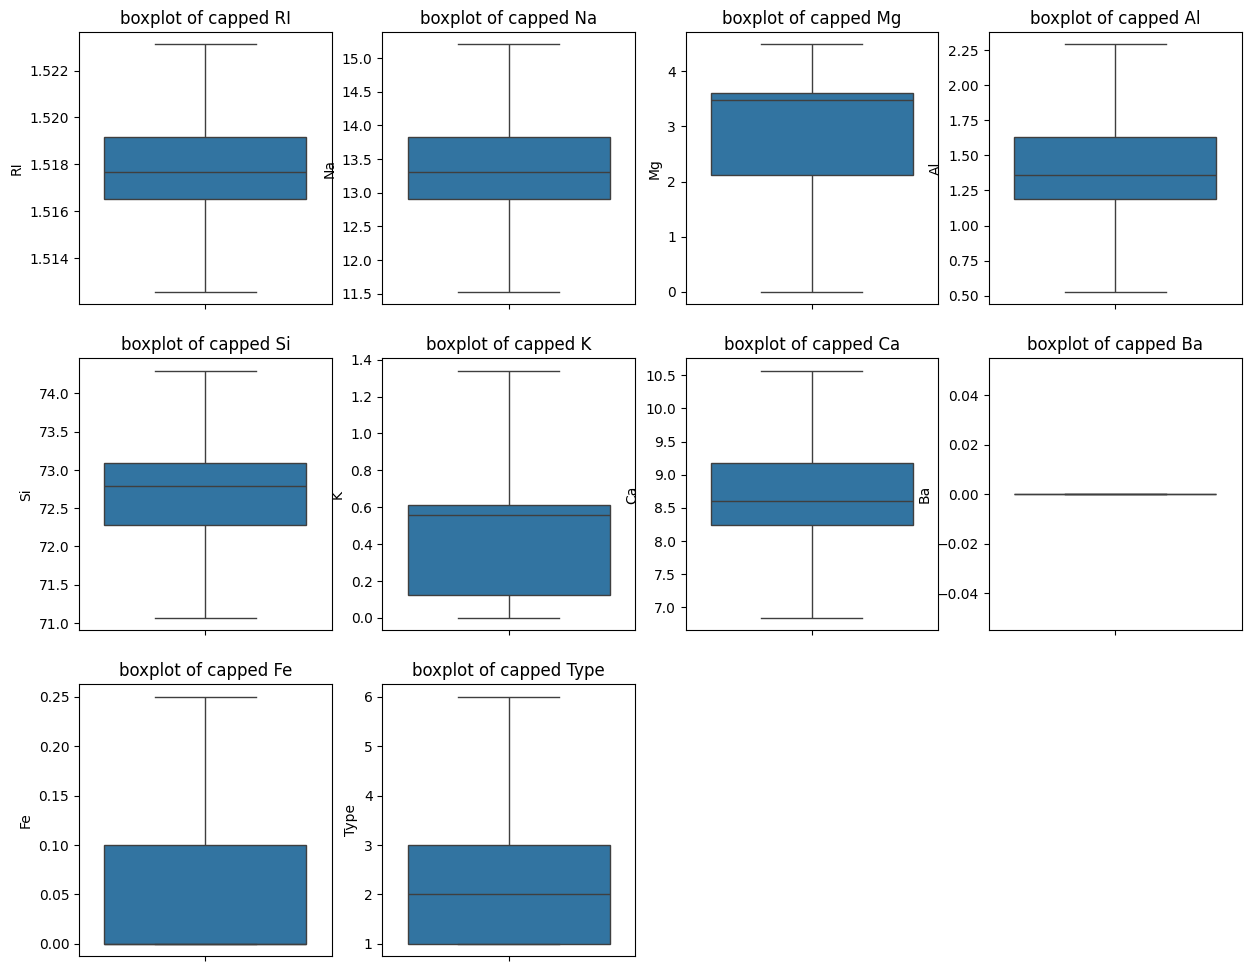

In [28]:
plt.figure(figsize=(15,12))
numerical_columns_for_plot=df_capped.select_dtypes(include=['float64','int64']).columns
num_cols=len(numerical_columns_for_plot)
num_rows=(num_cols+3)//4


for i, columns in enumerate(numerical_columns_for_plot):
   plt.subplot(num_rows,4,i+1)
   sns.boxplot(y=df_capped[columns])
   plt.title(f'boxplot of capped {columns}')

plt.tight_layout
plt.show()

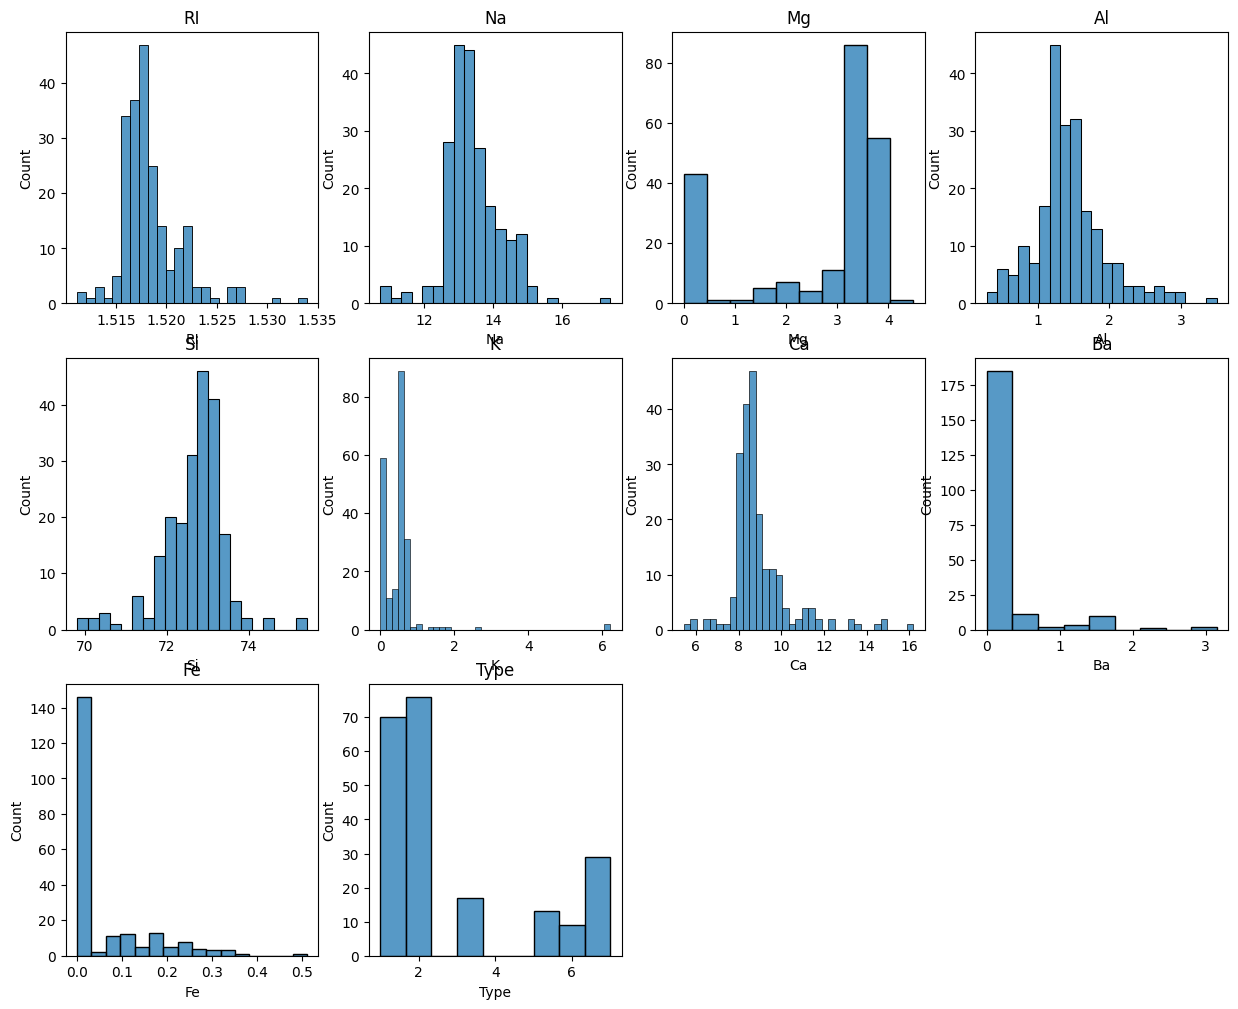

In [29]:
plt.figure(figsize=(15,12))
for i, columns in enumerate(df.columns):
   plt.subplot(num_rows,4,i+1)
   sns.histplot(df[columns])
   plt.title(columns)

plt.tight_layout
plt.show()
#

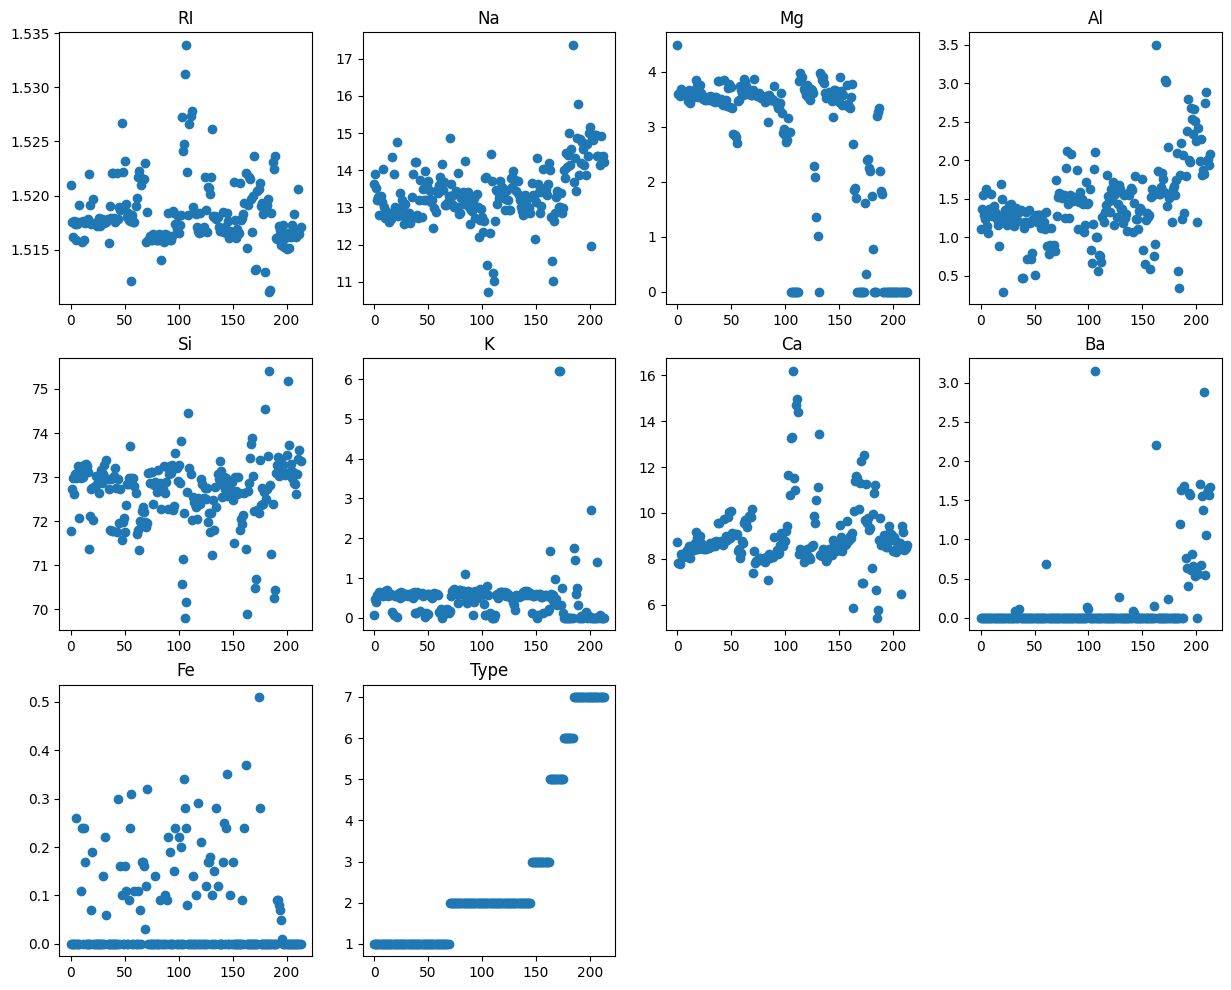

In [30]:
plt.figure(figsize=(15,12))
for i, columns in enumerate(df.columns):
   plt.subplot(num_rows,4,i+1)
   plt.scatter(df.index,df[columns])
   plt.title(columns)

plt.tight_layout
plt.show()

<Axes: >

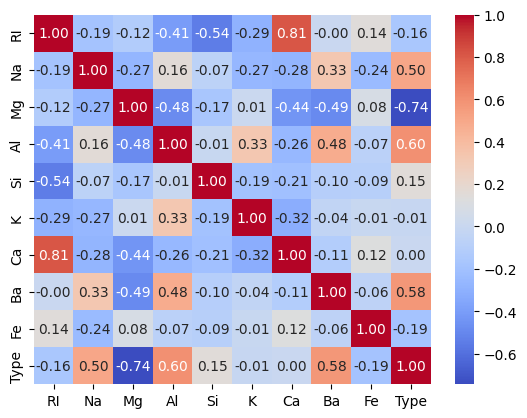

In [31]:

df[num].corr()
sns.heatmap(df[num].corr(),annot=True,cmap='coolwarm',fmt='.2f')


Ca and Ri shows strong positive relation

na and ba shows positive relation**

si and ri shows strong negative relation

ba and mg strong negative

ca and mg negative relation


3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.



In [32]:
df.isnull().sum()

,0
RI,0
Na,0
Mg,0
Al,0
Si,0
K,0
Ca,0
Ba,0
Fe,0
Type,0


no missing values and no categorical variables


In [33]:
x=df.drop('Type',axis=1)
y=df['Type']

In [34]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
df_ss=ss.fit_transform(x)


In [35]:
df_ss.shape

(214, 9)

**4: Random Forest Model Implementation**

1. Divide the data into train and test split.

2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.

3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

In [36]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,random_state=42,test_size=0.2)
x_train.shape

(171, 9)

In [37]:
x_test.shape

(43, 9)

In [48]:
from sklearn.ensemble import RandomForestClassifier
rf=RandomForestClassifier(random_state=42)
rf.fit(x_train,y_train)
y_pred_rf=rf.predict(x_test)
y_pred_rf

array([1, 7, 1, 7, 2, 2, 1, 2, 2, 1, 6, 2, 1, 2, 6, 5, 7, 1, 1, 6, 2, 7,
       7, 7, 3, 2, 1, 1, 5, 1, 1, 2, 3, 2, 1, 7, 5, 1, 1, 7, 1, 7, 1])

In [39]:
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report
print(f'accuracy_score:{accuracy_score(y_test,y_pred)}')
print(f'confusion_matrix:{confusion_matrix(y_test,y_pred)}')
print(f'classification_report:{classification_report(y_test,y_pred)}')


accuracy_score:0.8372093023255814
confusion_matrix:[[11  0  0  0  0  0]
 [ 4  9  0  0  0  1]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]
classification_report:              precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.90      0.64      0.75        14
           3       1.00      0.67      0.80         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.84        43
   macro avg       0.91      0.84      0.86        43
weighted avg       0.87      0.84      0.83        43




**5: Bagging and Boosting Methods**

Apply the Bagging and Boosting methods and compare the results.

In [49]:
from sklearn.ensemble import AdaBoostClassifier
ab=AdaBoostClassifier(random_state=42)
ab.fit(x_train,y_train)
y_pred_ab=ab.predict(x_test)
y_pred_ab

array([1, 7, 1, 7, 1, 5, 1, 1, 1, 2, 5, 2, 1, 1, 7, 2, 7, 1, 1, 7, 2, 7,
       7, 7, 1, 2, 2, 1, 2, 1, 2, 1, 1, 1, 1, 7, 5, 1, 2, 7, 2, 7, 1])

In [41]:
print(f'accuracy_score:{accuracy_score(y_test,y_pred)}')
print(f'confusion_matrix:{confusion_matrix(y_test,y_pred)}')
print(f'classification_report:{classification_report(y_test,y_pred)}')


accuracy_score:0.5348837209302325
confusion_matrix:[[9 2 0 0 0 0]
 [7 5 0 1 0 1]
 [3 0 0 0 0 0]
 [0 3 0 1 0 0]
 [0 0 0 1 0 2]
 [0 0 0 0 0 8]]
classification_report:              precision    recall  f1-score   support

           1       0.47      0.82      0.60        11
           2       0.50      0.36      0.42        14
           3       0.00      0.00      0.00         3
           5       0.33      0.25      0.29         4
           6       0.00      0.00      0.00         3
           7       0.73      1.00      0.84         8

    accuracy                           0.53        43
   macro avg       0.34      0.40      0.36        43
weighted avg       0.45      0.53      0.47        43



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [50]:
from sklearn.ensemble import GradientBoostingClassifier
gb=GradientBoostingClassifier(random_state=42)
gb.fit(x_train,y_train)
y_pred_gb=gb.predict(x_test)
y_pred_gb

array([1, 7, 1, 7, 2, 2, 1, 2, 2, 1, 6, 2, 2, 2, 3, 5, 7, 1, 1, 7, 2, 7,
       7, 7, 3, 2, 1, 1, 5, 1, 1, 2, 3, 2, 1, 7, 5, 3, 1, 2, 1, 7, 1])

In [43]:
print(f'accuracy_score:{accuracy_score(y_test,y_pred)}')
print(f'confusion_matrix:{confusion_matrix(y_test,y_pred)}')
print(f'classification_report:{classification_report(y_test,y_pred)}')


accuracy_score:0.8604651162790697
confusion_matrix:[[11  0  0  0  0  0]
 [ 3 11  0  0  0  0]
 [ 0  0  3  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  1  0  1  1]
 [ 0  0  0  0  0  8]]
classification_report:              precision    recall  f1-score   support

           1       0.79      1.00      0.88        11
           2       0.92      0.79      0.85        14
           3       0.75      1.00      0.86         3
           5       1.00      0.75      0.86         4
           6       1.00      0.33      0.50         3
           7       0.89      1.00      0.94         8

    accuracy                           0.86        43
   macro avg       0.89      0.81      0.81        43
weighted avg       0.88      0.86      0.85        43



In [51]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

results={
    'model':['RandomForestClassifier','AdaBoostClassifier','GradientBoostingClassifier'],
    'accuracy_score':[
        accuracy_score(y_test,y_pred_rf),
        accuracy_score(y_test,y_pred_ab),
        accuracy_score(y_test,y_pred_gb)
    ],
    'f1_score':[
        f1_score(y_test,y_pred_rf, average='weighted'),
        f1_score(y_test,y_pred_ab, average='weighted'),
        f1_score(y_test,y_pred_gb, average='weighted')
    ],
    'precision_score':[
        precision_score(y_test,y_pred_rf, average='weighted'),
        precision_score(y_test,y_pred_ab, average='weighted'),
        precision_score(y_test,y_pred_gb, average='weighted')
    ],
    'recall_score':[
        recall_score(y_test,y_pred_rf, average='weighted'),
        recall_score(y_test,y_pred_ab, average='weighted'),
        recall_score(y_test,y_pred_gb, average='weighted')
    ]
}


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [52]:
pd.DataFrame(results)

,model,accuracy_score,f1_score,precision_score,recall_score
0,RandomForestClassifier,0.837209,0.833045,0.866828,0.837209
1,AdaBoostClassifier,0.534884,0.472396,0.450280,0.534884
2,GradientBoostingClassifier,0.860465,0.850129,0.879937,0.860465


overally gradientboosting got better accuracy_score than the other

# **Additional Notes:**

**1. Explain Bagging and Boosting methods. How is it different from each other.**

**bagging**: it is an ensemble
technique which improves the model performance by training multiple models with different random samples of the dataset


**boosting**: it is an ensemble technique which sequential works upon the error of the previous model

**2. Explain how to handle imbalance in the data.**

oversampling,undersampling,usingevalution metrics

